<a href="https://colab.research.google.com/github/HaruWatXXD67/quant-projects/blob/main/cate_scm_causalimpact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import minimize
from sklearn.linear_model import RidgeCV

In [24]:
df = pd.read_csv('CATE_data.csv')
Y = df['Y'].values
W = df['Treat'].values
X = df.drop(columns=['Y', 'Treat']).values

In [25]:
X1, Y1 = X[W == 1], Y[W == 1]
X0, Y0 = X[W == 0], Y[W == 0]

In [27]:
model_t1_lr = LinearRegression().fit(X1, Y1)
model_t0_lr = LinearRegression().fit(X0, Y0)
cate_t = model_t1_lr.predict(X) - model_t0_lr.predict(X)

In [28]:
model_t1_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X1, Y1)
model_t0_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X0, Y0)
cate_cf = model_t1_rf.predict(X) - model_t0_rf.predict(X)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33268 (\N{CJK UNIFIED IDEOGRAPH-81F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

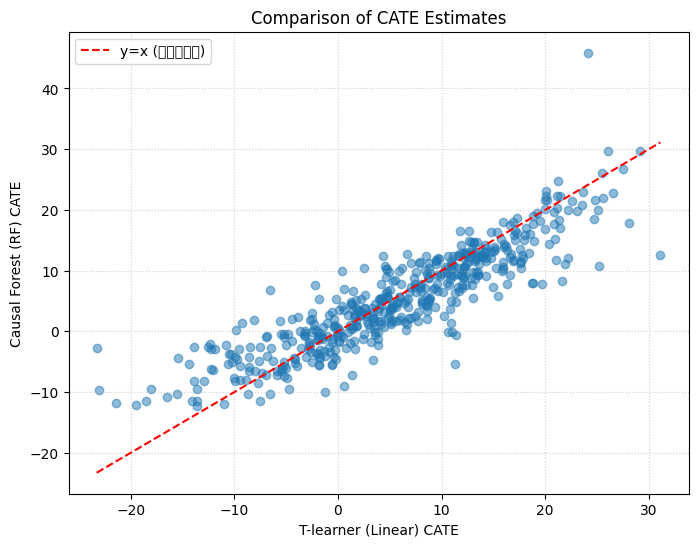

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(cate_t, cate_cf, alpha=0.5, color='tab:blue')
plt.plot([cate_t.min(), cate_t.max()], [cate_t.min(), cate_t.max()], 'r--', label='y=x (一致ライン)')
plt.xlabel('T-learner (Linear) CATE')
plt.ylabel('Causal Forest (RF) CATE')
plt.title('Comparison of CATE Estimates')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [30]:
# Calibration, Monotonicity
def evaluate_cate(cate_pred, Y, W, title, color):
  eval_df = pd.DataFrame({'pred': cate_pred, 'Y': Y, 'W': W})
  eval_df['bin'] = pd.qcut(eval_df['pred'], 10, labels=False, duplicates='drop')
  calib = eval_df.groupby('bin').apply(
      lambda g: pd.Series({
          'avg_pred': g['pred'].mean(),
          'actual_ate': g[g['W']==1]['Y'].mean() - g[g['W']==0]['Y'].mean()
          })
      ).reset_index()

In [31]:
def evaluate_cate(cate_pred, Y, W, title, color):
    eval_df = pd.DataFrame({'pred': cate_pred, 'Y': Y, 'W': W})
    eval_df['bin'] = pd.qcut(eval_df['pred'], 10, labels=False, duplicates='drop')
    calib = eval_df.groupby('bin').apply(
        lambda g: pd.Series({
            'avg_pred': g['pred'].mean(),
            'actual_ate': g[g['W']==1]['Y'].mean() - g[g['W']==0]['Y'].mean()
        })
    )

    # Quartile monotonicity check — now inside the same function, same eval_df
    eval_df['q'] = pd.qcut(eval_df['pred'], 4, labels=False, duplicates='drop')
    n_bins = eval_df['q'].nunique()
    label_map = {i: f"Q{i+1}" for i in range(n_bins)}
    eval_df['q'] = eval_df['q'].map(label_map)
    mono = eval_df.groupby('q', observed=True).apply(
        lambda g: g[g['W']==1]['Y'].mean() - g[g['W']==0]['Y'].mean()
    )

    return calib, mono

In [32]:
calib_t, mono_t = evaluate_cate(cate_t, Y, W, "T-learner", "blue")
calib_cf, mono_cf = evaluate_cate(cate_cf, Y, W, "Causal Forest", "green")

/tmp/ipykernel_1001/3844836727.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  calib = eval_df.groupby('bin').apply(
/tmp/ipykernel_1001/3844836727.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mono = eval_df.groupby('q', observed=True).apply(
/tmp/ipykernel_1001/3844836727.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a fut

In [33]:
eval_df = pd.DataFrame({'pred': cate_t, 'Y': Y, 'W': W})  # or cate_cf, depending which you're analyzing
eval_df['q'] = pd.qcut(eval_df['pred'], 4, labels=False, duplicates='drop')
n_bins = eval_df['q'].nunique()
label_map = {i: f"Q{i+1}" for i in range(n_bins)}
eval_df['q'] = eval_df['q'].map(label_map)
mono = eval_df.groupby('q', observed=True).apply(
    lambda g: g[g['W']==1]['Y'].mean() - g[g['W']==0]['Y'].mean()
)
print(mono)

q
Q1    -4.058250
Q2     2.170877
Q3     8.896395
Q4    18.405363
dtype: float64


/tmp/ipykernel_1001/231924931.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mono = eval_df.groupby('q', observed=True).apply(


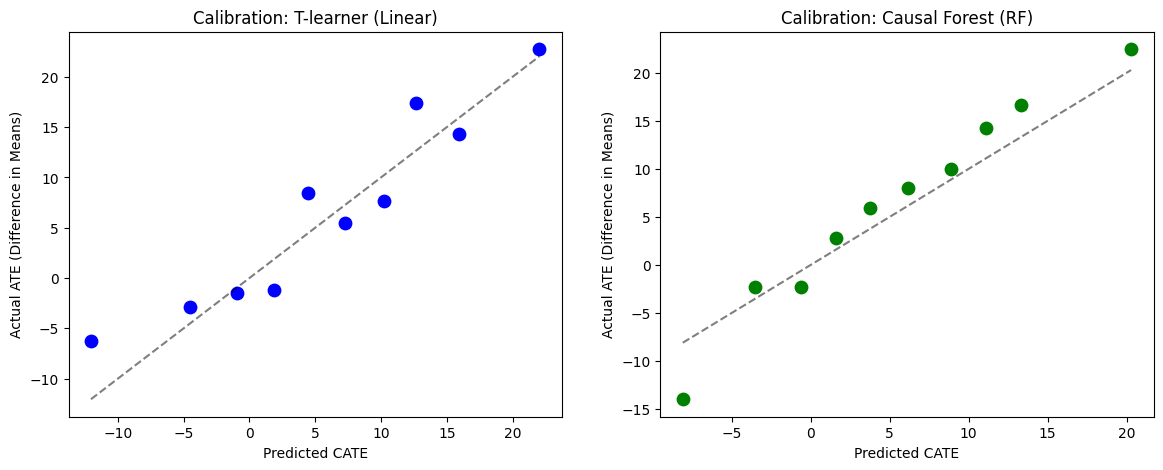

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(calib_t['avg_pred'], calib_t['actual_ate'], color='blue', s=80)
ax1.plot([calib_t['avg_pred'].min(), calib_t['avg_pred'].max()],
[calib_t['avg_pred'].min(), calib_t['avg_pred'].max()], 'k--', alpha=0.5)
ax1.set_title('Calibration: T-learner (Linear)')
ax1.set_xlabel('Predicted CATE')
ax1.set_ylabel('Actual ATE (Difference in Means)')
ax2.scatter(calib_cf['avg_pred'], calib_cf['actual_ate'], color='green', s=80)
ax2.plot([calib_cf['avg_pred'].min(), calib_cf['avg_pred'].max()],
[calib_cf['avg_pred'].min(), calib_cf['avg_pred'].max()], 'k--', alpha=0.5)
ax2.set_title('Calibration: Causal Forest (RF)')
ax2.set_xlabel('Predicted CATE')
ax2.set_ylabel('Actual ATE (Difference in Means)')
plt.show()

In [35]:
df = pd.read_csv('Basque_data.csv')
treatment_year = 1969
df_idx = df.set_index('year')

In [36]:
y = df_idx['treated']
X = df_idx.drop(columns=['treated'])
pre_mask = df_idx.index < treatment_year
post_mask = df_idx.index >= treatment_year

In [37]:
# SCM
def scm_objective(weights, X_pre, y_pre):
  return np.sum((y_pre - X_pre @ weights)**2)

In [38]:
n_controls = X.shape[1]
res = minimize(scm_objective, np.ones(n_controls)/n_controls,
               args=(X.loc[pre_mask].values, y.loc[pre_mask].values),
               method='SLSQP', bounds=[(0, 1)] * n_controls,
               constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
df_idx['SCM_Synthetic'] = X.values @ res.x

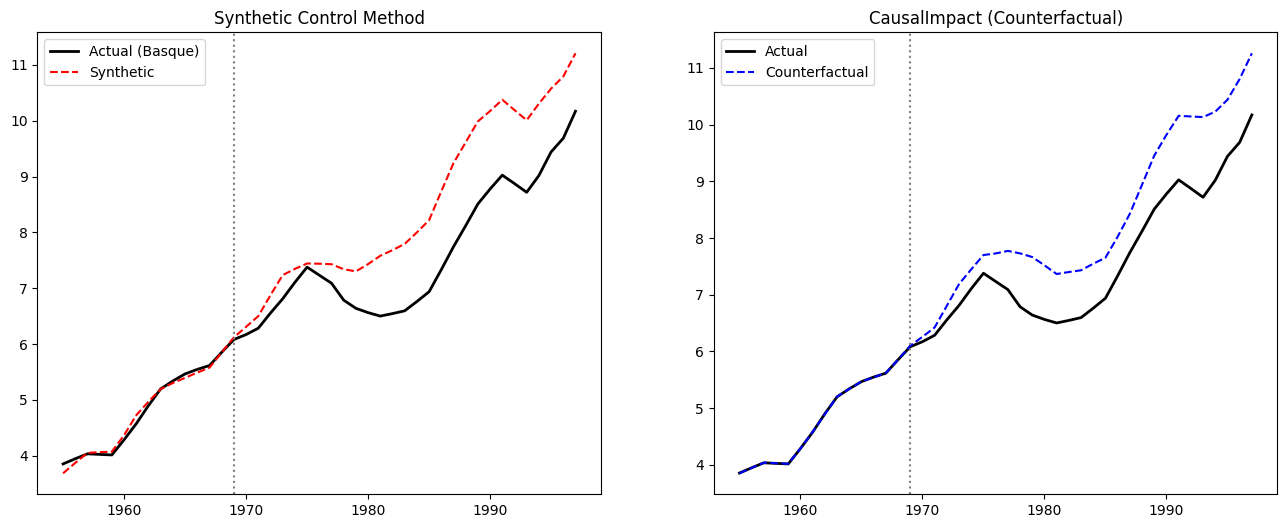

In [39]:
# CausalImpact
model = RidgeCV(alphas=np.logspace(-3, 3, 10))
model.fit(X.loc[pre_mask], y.loc[pre_mask])
df_idx['CI_Counterfactual'] = model.predict(X)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# SCM Plot
ax[0].plot(df_idx.index, df_idx['treated'], label='Actual (Basque)', color='black', lw=2)
ax[0].plot(df_idx.index, df_idx['SCM_Synthetic'], label='Synthetic', linestyle='--', color='red')
ax[0].axvline(treatment_year, color='gray', ls=':')
ax[0].set_title('Synthetic Control Method')
ax[0].legend()

# CausalImpact Plot
ax[1].plot(df_idx.index, df_idx['treated'], label='Actual', color='black', lw=2)
ax[1].plot(df_idx.index, df_idx['CI_Counterfactual'], label='Counterfactual', linestyle='--',
color='blue')
ax[1].axvline(treatment_year, color='gray', ls=':')
ax[1].set_title('CausalImpact (Counterfactual)')
ax[1].legend()

In [40]:
scm_att = (df_idx.loc[post_mask, 'treated'] - df_idx.loc[post_mask, 'SCM_Synthetic']).mean()
ci_att = (df_idx.loc[post_mask, 'treated'] - df_idx.loc[post_mask, 'CI_Counterfactual']).mean()
print(f"SCM: {scm_att:.4f}")
print(f"Ridge: {ci_att:.4f}")

SCM: -0.8898
Ridge: -0.7617
